# COGS 108 - EDA Checkpoint

## Authors

- Andrew Zhang: Find data and describe dataset 2
- Andy Cao: Data wrangling for Dataset 1, Writing – original draft
- Vicky Huang: Find data and describe dataset 1
- Jasmine Lou: Data wrangling for Dataset 2, Writing – original draft
- Yiwen Huang: Update info, Writing – review and editing

# Research Question

How have housing prices and affordability changed over time in regions surrounding University of California (UC) campuses, and how do these trends relate to local income levels and broader economic conditions?

Specifically, we examine whether housing prices near UC campuses have increased faster than median household income and how these trends differ across regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and time periods. The main metrics are median home price (or home value index), median household income, and affordability (e.g., price-to-income ratio or rent burden). The analysis is primarily descriptive and comparative. We will visualize price and income trends, compare regions, and assess changes in affordability over the **5-year period from 2020 to the end of 2024** using public data from government and real-estate sources (e.g., Zillow, U.S. Census/ACS, FRED).


## Background and Prior Work

Housing affordability has become a major economic and social issue in California, particularly in regions with high demand and limited housing supply. Areas surrounding University of California campuses often experience additional housing pressure due to student populations, faculty demand, and local economic growth. Prior research has shown that housing prices in California have increased significantly over the past two decades, frequently outpacing wage growth and contributing to affordability challenges for renters and homeowners alike.

Several public data sources provide context. Zillow's housing market reports document long-term growth in home values across major U.S. metropolitan areas, with especially rapid increases in coastal California cities. U.S. Census data and American Community Survey (ACS) reports provide evidence that median household income growth has been slower and uneven across regions. Our project focuses on UC-adjacent regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and compares affordability trends across multiple campuses using Zillow, Census/ACS, and FRED data.

# Hypothesis


We hypothesize that housing prices in regions surrounding UC campuses have increased faster than median household income between 2020 and 2024, leading to decreased affordability. We also expect that UC regions in major metropolitan or coastal areas (e.g., near UC Berkeley or UCLA) will exhibit higher prices and lower affordability compared to UC campuses in less dense regions (e.g., UC Riverside or UC Merced). This is based on prior evidence that coastal and urban California markets have seen stronger price growth and that university towns often face extra demand from students and staff, while income growth has been slower and uneven across the state.

## Data

### Data overview

**Dataset 1: Zillow Home Value Index (ZHVI), Single-Family Residences**
- **Dataset name:** Zip_Zhvi_SingleFamilyResidence (ZIP code level, single-family home values).
- **Source / link:** Zillow Research Data (public mirror used in this project: `Zip_Zhvi_SingleFamilyResidence_2018.csv`).
- **Observations:** One row per ZIP code. Thousands of ZIPs nationally; we filter to California and further to UC-adjacent areas.
- **Variables:** `RegionID`, `RegionName` (ZIP), `State`, `Metro`, `CountyName`, and many date columns (e.g., 1996-04 to 2018-12) with typical home value in dollars for that month.
- **Relevance:** Provides housing price levels and growth over time at fine geography (ZIP). We can aggregate to county or metro and align with UC campus regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles).
- **Limitations:** Mirror ends in 2018; geography is ZIP, so we must map ZIPs to counties/metros; single-family only.

**Dataset 2: California County Income**
- **Source:** Census ACS B19013 (median household income), 2020–2024, built to `income_acs_ca_2020_2024.csv` (one row per county per year; we use the 2020–2024 average).
- **Observations:** One row per county (after aggregation).
- **Key variables:** `county`, `median_household_income`.
- **Relevance:** County-level income merged with housing prices to study affordability.
- **Limitations:** ACS estimates have sampling error.

**How we use them together.** We filter Zillow data to California, aggregate ZIP-level home values to the county level, and merge with county income (ACS 2020–2024 average) on county names. This supports cross-sectional affordability and income–home-value relationships.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!!
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries;
# each dict has keys of
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  3.68it/s]

Successfully downloaded: airline-safety.csv


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  3.39it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 — Zillow Home Value Index (ZHVI), Single-Family by ZIP

We use the Zillow Home Value Index (ZHVI) dataset for single-family residences at the ZIP code level. Each row corresponds to a ZIP code and contains typical home values (in USD) across many months and years. From the raw file `data/00-raw/Zip_Zhvi_SingleFamilyResidence_2018.csv`, we:

- Filter to California ZIP codes (`State == 'CA'`).
- Keep key geography columns (`RegionID`, `RegionName`, `State`, `CountyName`, `Metro`) and all date columns.
- Drop rows where all date columns are missing or zero.

The cleaned California subset is saved as `data/02-processed/zhvi_sfr_zip_ca.csv` (or, if using the 2018 mirror only, `zhvi_sfr_zip_ca_2018.csv`). For 2020–2024 analysis, use ZHVI from [Zillow Research Data](https://www.zillow.com/research/data/) (ZIP, Single-Family) and run 01-DataCheckpoint to produce `zhvi_sfr_zip_ca.csv`. This file is the main housing-price input to our EDA.

In [3]:
import os
import pandas as pd

_zhvi0 = "data/02-processed/zhvi_sfr_zip_ca.csv" if os.path.isfile("data/02-processed/zhvi_sfr_zip_ca.csv") else "data/02-processed/zhvi_sfr_zip_ca_2018.csv"
zhvi_ca = pd.read_csv(_zhvi0)

print("ZHVI (CA ZIPs) shape:", zhvi_ca.shape)
print("Columns (first 8):", list(zhvi_ca.columns[:8]))

key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro"]
date_cols = [c for c in zhvi_ca.columns if c not in key_cols]
print("Number of monthly value columns:", len(date_cols))

last_col = date_cols[-1]
print(f"\nSummary of {last_col} (typical home value, USD):")
print(zhvi_ca[last_col].describe())

ZHVI (CA ZIPs) shape: (1528, 322)
Columns (first 8): ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro']
Number of monthly value columns: 317

Summary of 2026-01-31 (typical home value, USD):
count    1.528000e+03
mean     9.029998e+05
std      7.436232e+05
min      6.396585e+04
25%      4.196979e+05
50%      7.073955e+05
75%      1.098911e+06
max      7.760229e+06
Name: 2026-01-31, dtype: float64


### Dataset #2 — California County Income

Census American Community Survey (ACS) table B19013 (median household income) for California counties, years 2020–2024. We build `data/02-processed/income_acs_ca_2020_2024.csv` from the ACS CSVs (e.g. in `data/02-processed/COGS 108 data/...`). The notebook uses the **2020–2024 average** per county, so income aligns with our 2020–2024 average home values. In the EDA and results below, we load county income from `income_acs_ca_2020_2024.csv` and aggregate to one row per county by mean over 2020–2024.

In [4]:
import pandas as pd

_inc = pd.read_csv("data/02-processed/income_acs_ca_2020_2024.csv")
income = _inc.groupby("county")["median_household_income"].mean().reset_index()

print("Income dataset shape:", income.shape)
print("Columns:", list(income.columns))
print("\nPreview:")
print(income.head())

print("\nSummary of median_household_income (USD):")
print(income["median_household_income"].describe())

Income dataset shape: (58, 2)
Columns: ['county', 'median_household_income']

Preview:
      county  median_household_income
0    Alameda                 119000.0
1     Alpine                  99835.4
2     Amador                  75913.0
3      Butte                  63484.4
4  Calaveras                  74644.6

Summary of median_household_income (USD):
count        58.000000
mean      81272.493103
std       24130.618507
min       47560.600000
25%       62856.550000
50%       75278.800000
75%       96493.650000
max      149779.000000
Name: median_household_income, dtype: float64


## Results

### Exploratory Data Analysis

In this section, we explore how housing prices and affordability vary across California counties, with a focus on regions surrounding UC campuses. We load the fully wrangled datasets from `data/02-processed`:

- `zhvi_sfr_zip_ca_2018.csv`: cleaned Zillow Home Value Index (single-family) for California ZIP codes.
- County income: `income_acs_ca_2020_2024.csv` (ACS median household income, 2020–2024 average).

Our EDA has two main goals:

1. Summarize the distribution of home values and income across UC-adjacent counties and compute simple affordability metrics (e.g., price-to-income ratios).
2. Examine the relationship between county-level income and home values, including visualization and correlation, to see how strongly income is associated with housing prices.

We interleave code, figures, and written interpretation. Reusable processing steps (e.g., loading processed data, aggregating ZIP values to the county level) draw on the modules and data-wrangling work from previous checkpoints rather than re-downloading raw files.

#### Section 1 — Affordability Across UC-Adjacent Counties

In this section we construct a simple cross-sectional view of housing affordability in counties that contain or border major UC campuses (for example, Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo). Using the cleaned ZHVI dataset, we summarize the most recent available home values at the ZIP level and aggregate them to the county level. We then merge these county-level home values with county income (ACS median household income, 2020–2024 average).

From the merged data, we compute and visualize a price-to-income ratio (typical home value divided by median household income) for each UC-adjacent county. This provides a first look at how affordability compares across regions: higher ratios indicate that home values are high relative to local incomes. We discuss which UC regions appear most and least affordable and how these findings relate to our research question about housing pressure near UC campuses.

Merged UC-adjacent counties:
       county   home_value  median_household_income  price_to_income
Santa Barbara 1.307557e+06                  89950.2        14.536457
  Los Angeles 1.083556e+06                  81801.6        13.246149
       Orange 1.238239e+06                 106855.6        11.587966
    San Diego 9.739509e+05                  95238.6        10.226430
      Alameda 1.150364e+06                 119000.0         9.666926
         Yolo 5.685005e+05                  83559.8         6.803516
    Riverside 5.496092e+05                  82809.8         6.637007
       Merced 3.894184e+05                  62103.4         6.270485


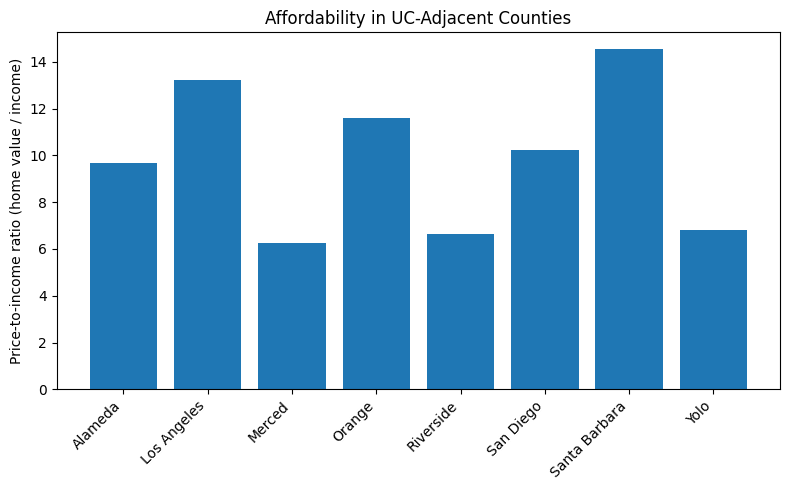

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import os
_zhvi = "data/02-processed/zhvi_sfr_zip_ca.csv"
if not os.path.isfile(_zhvi):
    _zhvi = "data/02-processed/zhvi_sfr_zip_ca_2018.csv"
zhvi_ca = pd.read_csv(_zhvi)
_inc = pd.read_csv("data/02-processed/income_acs_ca_2020_2024.csv")
income = _inc.groupby("county")["median_household_income"].mean().reset_index()

zhvi_ca["county"] = zhvi_ca["CountyName"].str.replace(" County", "", regex=False)

uc_counties = [
    "Alameda",
    "Los Angeles",
    "Orange",
    "San Diego",
    "Santa Barbara",
    "Riverside",
    "Merced",
    "Yolo"
]

key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro", "county"]
date_cols = [c for c in zhvi_ca.columns if c not in key_cols]
target_years = ["2020", "2021", "2022", "2023", "2024"]
year_cols = [c for c in date_cols if any(c.startswith(y + "-") for y in target_years)]
if not year_cols:
    raise ValueError("data not found")
zhvi_ca = zhvi_ca.copy()
zhvi_ca["home_value_2020_2024"] = zhvi_ca[year_cols].mean(axis=1)
value_col = "home_value_2020_2024"
value_label = "2020-2024 average"

zhvi_uc = (
    zhvi_ca[zhvi_ca["county"].isin(uc_counties)]
    .loc[:, ["county", value_col]]
    .rename(columns={value_col: "home_value"})
)

county_values = (
    zhvi_uc
    .groupby("county", as_index=False)["home_value"].mean()
)

merged = county_values.merge(income, on="county", how="left")

merged["price_to_income"] = merged["home_value"] / merged["median_household_income"]

print(f"Merged UC-adjacent counties:")
display_cols = ["county", "home_value", "median_household_income", "price_to_income"]
print(merged[display_cols].sort_values("price_to_income", ascending=False).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(merged["county"], merged["price_to_income"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Price-to-income ratio (home value / income)")
plt.title(f"Affordability in UC-Adjacent Counties")
plt.tight_layout()
plt.show()

#### Section 2 County-Level Relationship Between County Income and Home Values

In this section, we construct a county-level dataset by combining county income (ACS median household income, 2020–2024 average) with Zillow home values for California. We aggregate ZIP-level home values to the county level (mean home value per county, 2020–2024 average) and merge with the county income dataset using county names. We visualize the relationship between county income and average home value and compute the Pearson correlation to quantify the strength of the association.

At the county level, median household income is strongly positively associated with average home value in California (Pearson correlation ≈ 0.92).

Income shape: (58, 2)
Zillow shape: (1528, 322)


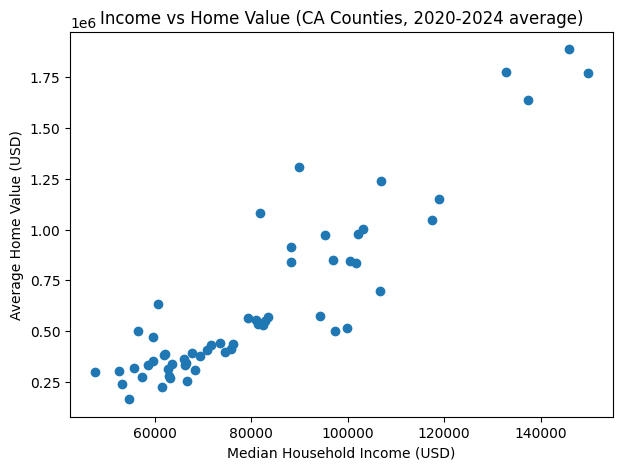

Correlation: 0.906582704924455


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

_inc = pd.read_csv("data/02-processed/income_acs_ca_2020_2024.csv")
income = _inc.groupby("county")["median_household_income"].mean().reset_index()
_zhvi2 = "data/02-processed/zhvi_sfr_zip_ca.csv" if os.path.isfile("data/02-processed/zhvi_sfr_zip_ca.csv") else "data/02-processed/zhvi_sfr_zip_ca_2018.csv"
zillow_ca = pd.read_csv(_zhvi2)

print("Income shape:", income.shape)
print("Zillow shape:", zillow_ca.shape)

key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro"]
date_cols = [c for c in zillow_ca.columns if c not in key_cols]
target_years = ["2020", "2021", "2022", "2023", "2024"]
year_cols = [c for c in date_cols if any(c.startswith(y + "-") for y in target_years)]
if not year_cols:
    raise ValueError("Data not found")
zillow_ca = zillow_ca.copy()
zillow_ca["home_value_2020_2024"] = zillow_ca[year_cols].mean(axis=1)
value_col = "home_value_2020_2024"
value_label = "2020-2024 average"

zillow_ca["county"] = zillow_ca["CountyName"].str.replace(" County", "", regex=False)
zillow_county = zillow_ca.groupby("county")[value_col].mean().reset_index()
zillow_county = zillow_county.rename(columns={value_col: "home_value"})

merged = pd.merge(income, zillow_county, on="county", how="inner")

plt.figure(figsize=(7,5))
plt.scatter(merged["median_household_income"], merged["home_value"])
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Average Home Value (USD)")
plt.title(f"Income vs Home Value (CA Counties, {value_label})")
plt.show()

corr = merged["median_household_income"].corr(merged["home_value"])
print("Correlation:", corr)

## Information Updates

Since the previous checkpoint, we made several updates to improve the focus and clarity of our analysis.

First, we updated the time range of our study. Instead of examining housing trends from 2010 to 2020, we **refined our analysis to focus on the more recent period from 2020 to 2024.** This adjustment allows us to better capture current housing market dynamics and affordability challenges that have emerged in the post pandemic period.

We **also updated our datasets** and preprocessing steps to ensure that the housing price and income data align with this new time frame. The Zillow Home Value Index and ACS median household income data were filtered and organized so that the analysis reflects trends through the end of 2024.

In addition, we continued working on our exploratory data analysis. We **created several visualizations** to compare housing prices and median household income across counties near UC campuses and looked at how affordability patterns differ across regions. These steps helped us start identifying general trends and better understand how income levels relate to housing prices before moving on to more formal statistical analysis.

These updates allow the project to focus on more recent housing affordability trends and ensure that our datasets and analysis better reflect current economic conditions.

## Conclusion

Our exploratory data analysis gives us an initial look at housing affordability trends in regions surrounding UC campuses. From the visualizations, we can see that housing prices vary quite a lot across different counties, and many areas near UC campuses appear to have relatively high home values compared to other regions. This suggests that location may play an important role in shaping local housing markets.

When comparing housing prices with median household income, the patterns in our plots suggest that home prices may be increasing faster than income in some regions. In places where housing prices rise more quickly than income, this could make housing less affordable for residents, especially for students and people working near UC campuses.

However, these observations are still preliminary because they come from exploratory analysis. Overall, the patterns we observed suggest that housing prices and income levels differ across counties near UC campuses, and these differences may contribute to variation in housing affordability across regions.

### Section 3 — County-Year Panels and Time Trends

In this section we extend our analysis to a **panel format** (county × year) and focus on the 2020–2024 period:

1. For each county and each year, we compute an **average home value** from monthly ZHVI data.
2. For each county and each year, we use ACS to obtain **median household income**.
3. We combine these into a **county-year price-to-income ratio** (home value ÷ income).

We then analyze:
- **Original trends over time** for UC-adjacent counties (home value, income, and price-to-income ratio by year).
- **Growth rates**: yearly growth in home value and income by county, which shows whether housing prices are rising faster than incomes.

In [7]:
# Build county-year average home values from monthly ZHVI

zhvi_ca_panel = zhvi_ca.copy()
zhvi_ca_panel["county"] = zhvi_ca_panel["CountyName"].str.replace(" County", "", regex=False)

# Identify monthly value columns and map them to years (focus on 2020–2024)
key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro", "county"]
value_cols = [c for c in zhvi_ca_panel.columns if c not in key_cols]

year_list = ["2020", "2021", "2022", "2023", "2024"]
year_to_cols = {
    y: [c for c in value_cols if c.startswith(y + "-")] for y in year_list
}

# Average monthly values within each year at the ZIP level, then aggregate to county level
home_year_cols = []
for y, cols in year_to_cols.items():
    if not cols:
        continue
    col_name = f"home_value_{y}"
    home_year_cols.append(col_name)
    zhvi_ca_panel[col_name] = zhvi_ca_panel[cols].mean(axis=1)

home_zip_year = zhvi_ca_panel[["county"] + home_year_cols]

# Long format: one row per ZIP–year, then aggregate to county–year
home_long = home_zip_year.melt(
    id_vars=["county"],
    value_vars=home_year_cols,
    var_name="year",
    value_name="home_value"
)
home_long["year"] = home_long["year"].str.replace("home_value_", "", regex=False).astype(int)
home_county_year = (
    home_long
    .groupby(["county", "year"], as_index=False)["home_value"].mean()
)

print("Home value (county-year) panel shape:", home_county_year.shape)
print(home_county_year.head())

# Income: use the original ACS 2020–2024 file as a county-year panel
inc_panel = _inc.copy()
inc_panel["year"] = inc_panel["year"].astype(int)

print("Income (county-year) panel shape:", inc_panel.shape)
print(inc_panel.head())

# Merge to compute price-to-income ratio per county-year
panel = home_county_year.merge(
    inc_panel, on=["county", "year"], how="inner"
)
panel["price_to_income"] = panel["home_value"] / panel["median_household_income"]

print("Merged county-year panel shape:", panel.shape)
print(panel.head())

Home value (county-year) panel shape: (290, 3)
    county  year    home_value
0  Alameda  2020  9.833614e+05
1  Alameda  2021  1.136718e+06
2  Alameda  2022  1.259659e+06
3  Alameda  2023  1.168478e+06
4  Alameda  2024  1.203604e+06
Income (county-year) panel shape: (290, 3)
    county  year  median_household_income
0  Alameda  2020                   104888
1  Alameda  2021                   112017
2  Alameda  2022                   122488
3  Alameda  2023                   126240
4  Alameda  2024                   129367
Merged county-year panel shape: (290, 5)
    county  year    home_value  median_household_income  price_to_income
0  Alameda  2020  9.833614e+05                   104888         9.375347
1  Alameda  2021  1.136718e+06                   112017        10.147731
2  Alameda  2022  1.259659e+06                   122488        10.283935
3  Alameda  2023  1.168478e+06                   126240         9.256004
4  Alameda  2024  1.203604e+06                   129367         9.

#### Time trends for UC-adjacent counties (levels)

We now look at **trends over time (2020–2024)** for UC-adjacent counties:
- Average home value by year.
- Median household income by year.
- Price-to-income ratio by year.

This directly addresses our research question about how housing prices and affordability have changed **over time** near UC campuses.

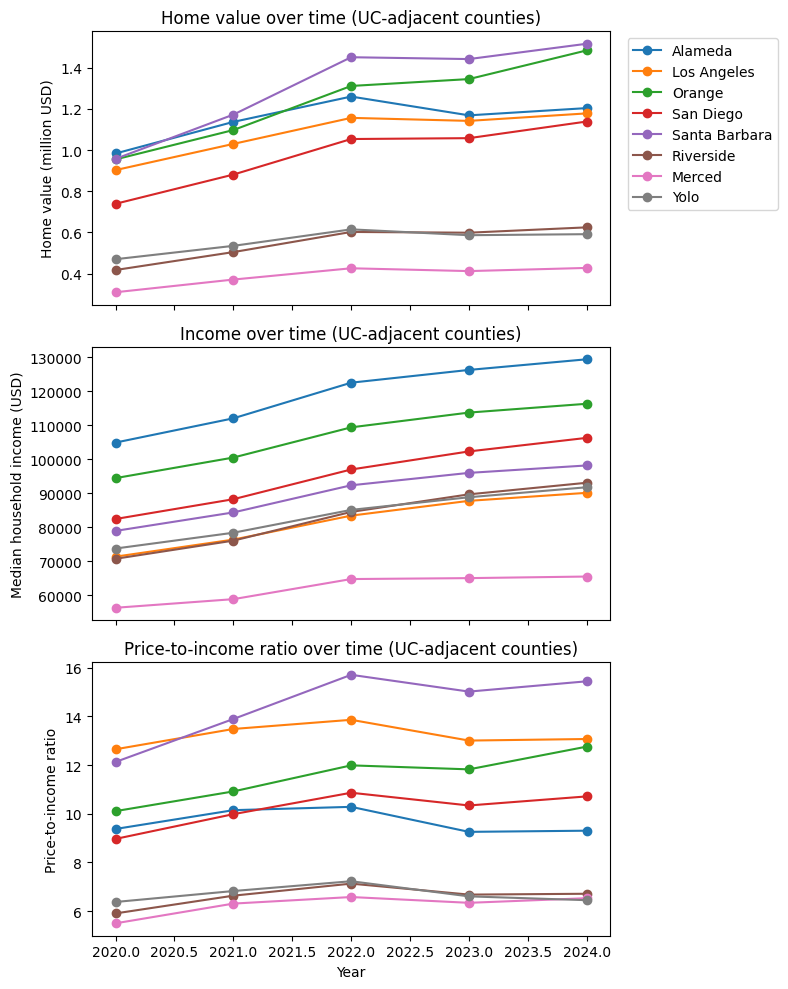

In [8]:
import matplotlib.pyplot as plt

uc_counties = [
    "Alameda",
    "Los Angeles",
    "Orange",
    "San Diego",
    "Santa Barbara",
    "Riverside",
    "Merced",
    "Yolo",
]

uc_panel = panel[panel["county"].isin(uc_counties)].copy()
uc_panel = uc_panel.sort_values(["county", "year"])

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for c in uc_counties:
    sub = uc_panel[uc_panel["county"] == c]
    axes[0].plot(sub["year"], sub["home_value"] / 1e6, marker="o", label=c)
    axes[1].plot(sub["year"], sub["median_household_income"], marker="o", label=c)
    axes[2].plot(sub["year"], sub["price_to_income"], marker="o", label=c)

axes[0].set_ylabel("Home value (million USD)")
axes[0].set_title("Home value over time (UC-adjacent counties)")
axes[1].set_ylabel("Median household income (USD)")
axes[1].set_title("Income over time (UC-adjacent counties)")
axes[2].set_ylabel("Price-to-income ratio")
axes[2].set_title("Price-to-income ratio over time (UC-adjacent counties)")
axes[2].set_xlabel("Year")

axes[0].legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation (time trends):** For most UC-adjacent counties, average home values and median household incomes both increase from 2020 to 2024, but home values are much larger in magnitude and often appear to rise more steeply in expensive coastal counties. The price-to-income ratio lines show how affordability evolves over time: in places like Santa Barbara and Los Angeles, ratios remain high throughout the period, suggesting persistently low affordability, while inland counties such as Merced and Riverside remain at lower ratios. This directly visualizes how housing pressure near UC campuses has changed over time.

#### Yearly growth rates (house value vs income)

Finally, we compute **yearly growth rates** for each county between 2020 and 2024:
- House value yearly growth rate.
- Income yearly growth rate.

This lets us compare whether housing prices are growing faster than incomes in UC-adjacent regions.

UC-adjacent counties growth (first few rows):
          county  year    home_value  median_household_income  \
0        Alameda  2020  9.833614e+05                   104888   
1        Alameda  2021  1.136718e+06                   112017   
2        Alameda  2022  1.259659e+06                   122488   
3        Alameda  2023  1.168478e+06                   126240   
4        Alameda  2024  1.203604e+06                   129367   
90   Los Angeles  2020  9.027612e+05                    71358   
91   Los Angeles  2021  1.029808e+06                    76367   
92   Los Angeles  2022  1.156209e+06                    83411   
93   Los Angeles  2023  1.141601e+06                    87760   
94   Los Angeles  2024  1.177969e+06                    90112   
115       Merced  2020  3.096868e+05                    56330   
116       Merced  2021  3.712679e+05                    58861   

     house_value_growth  income_growth  
0                   NaN            NaN  
1              0.155952   

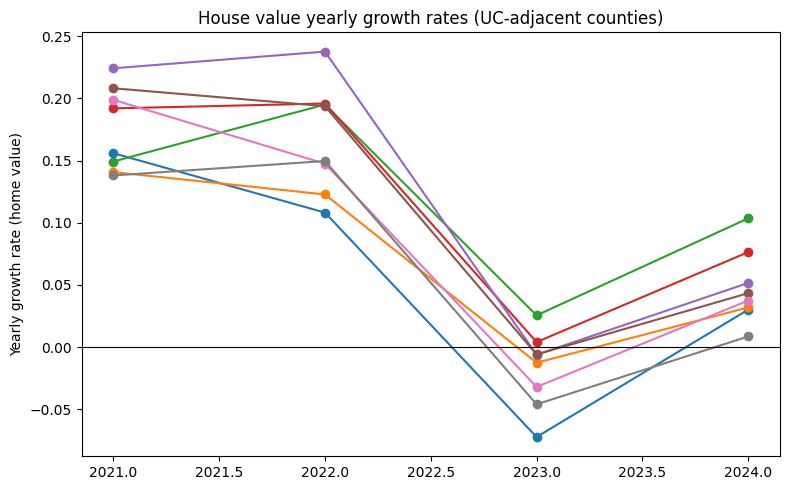

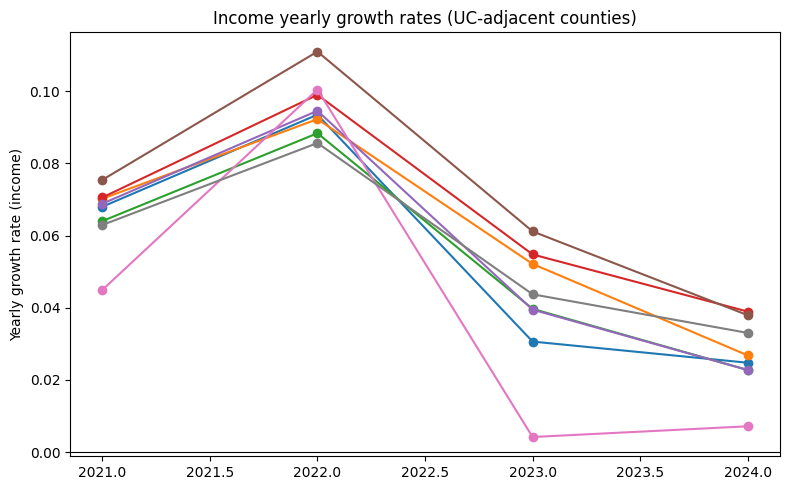

In [9]:
# Compute yearly growth rates per county
panel_growth = panel.sort_values(["county", "year"]).copy()
panel_growth["house_value_growth"] = panel_growth.groupby("county")["home_value"].pct_change()
panel_growth["income_growth"] = panel_growth.groupby("county")["median_household_income"].pct_change()

uc_growth = panel_growth[panel_growth["county"].isin(uc_counties)].copy()
print("UC-adjacent counties growth (first few rows):")
print(uc_growth[["county", "year", "home_value", "median_household_income", "house_value_growth", "income_growth"]].head(12))

plt.figure(figsize=(8, 5))
for c in uc_counties:
    sub = uc_growth[uc_growth["county"] == c]
    plt.plot(sub["year"], sub["house_value_growth"], marker="o", label=f"House value: {c}")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Yearly growth rate (home value)")
plt.title("House value yearly growth rates (UC-adjacent counties)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for c in uc_counties:
    sub = uc_growth[uc_growth["county"] == c]
    plt.plot(sub["year"], sub["income_growth"], marker="o", label=f"Income: {c}")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Yearly growth rate (income)")
plt.title("Income yearly growth rates (UC-adjacent counties)")
plt.tight_layout()
plt.show()

**Interpretation (growth rates):** The growth-rate plots show how quickly home values and incomes change year to year in UC-adjacent counties. In several coastal/metro counties, house value growth is positive in most years and sometimes exceeds income growth, which is consistent with worsening affordability. In other counties, income growth is more comparable to or occasionally higher than house value growth, suggesting more stable affordability. Together with the level trends, these growth rates help us see not just current affordability but how quickly conditions are improving or deteriorating over time.

## Ethics

We use only aggregated, publicly available data (Zillow, Census/ACS-style income estimates, and CA Open Data for income limits). There are no individual-level records or identifying information. We considered potential sources of bias, including that Zillow data may better cover active, higher-priced markets and that survey-based income estimates contain sampling error.

To address these concerns, we are explicit about the data sources and their limitations, avoid making individual-level claims, and frame our results as descriptive patterns about regions and counties rather than about specific people. We store data locally in the course repository and do not deploy any model as a public-facing product. Our discussion of affordability emphasizes structural trends (e.g., supply, demand, regional inequality) rather than blaming particular groups of residents.

## Team Expectations

All team members have read the [COGS108 Team Policies](https://github.com/COGS108/Projects/blob/master/COGS108_TeamPolicies.md) and agree to the following expectations.

- **Communication**: Communicate regularly through a shared platform (e.g., Discord or Slack) and attend scheduled meetings when possible.
- **Contribution**: Each member is expected to contribute equitably to data collection, analysis, and writing. If someone is overloaded, we will rebalance tasks.
- **Quality and deadlines**: We aim to have internal deadlines a few days before official due dates so there is time for review and revision.
- **Conflict resolution**: If conflicts arise, we agree to address them respectfully and promptly through group discussion. If needed, we will escalate to the instructor/IA following course policy.
- **Academic integrity**: We follow UCSD and COGS 108 academic integrity policies, ensuring that all code and writing we submit is our own work or properly cited.

By submitting this checkpoint, each member affirms that they intend to meet these expectations.

## Project Timeline Proposal

We organize our project timeline around data preparation, exploratory analysis, modeling (if needed), and writing. The plan below reflects updates since the proposal and data checkpoints.

| Week | Milestones | Details |
|------|-----------|---------|
| 3–4  | Finalize research question and identify datasets | Confirm access to Zillow ZHVI and CA income data; decide on UC-adjacent regions and counties. |
| 5    | Data cleaning and preprocessing | Download raw data, clean California ZHVI to `zhvi_sfr_zip_ca_2018.csv`, build county income to `income_acs_ca_2020_2024.csv`, and verify join keys. |
| 6    | Data checkpoint and basic summaries | Submit Data Checkpoint; produce initial summaries and sanity checks for both datasets. |
| 7    | Exploratory data analysis (EDA) | Build county-level merged datasets, compute price-to-income ratios, create plots and correlation analyses (as in this EDA checkpoint). |
| 8    | Deeper analysis and robustness checks | Refine definition of UC-adjacent areas, explore time trends where possible, and test sensitivity to different aggregation choices. |
| 9    | Draft full report | Integrate figures, tables, and interpretation; expand ethics and limitations sections. |
| 10   | Final revisions and submission | Polish writing and visualizations, finalize conclusions, and submit final project and group surveys. |

**Update for EDA Checkpoint:** At this point we have cleaned the key datasets, constructed an initial county-level merged dataset, and completed first-round EDA on affordability and income–price relationships. Next steps are to refine geographic definitions (e.g., specific UC commuter zones), explore additional time slices where available, and finalize figures for the report.